# <center>**LC17 to DN Pathways - Male CNS**</center>

Pathways were fetched with `Scripts/fetch_pathways_malecns.py`, only to the DNs we picked in the hemibrain (auto filter + Gio's filter). Same cleaning and network as the hemibrain, but the male CNS has both hemispheres, so everything keeps track of the side.

No DN hunting here - the flow is measured from the Right partners and from the Left partners onto every DN, and the networks use the same two filters as the hemibrain.

In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
from scipy.cluster.hierarchy import linkage, leaves_list

# Connectome
import connectome_analysis
import neuprint
from neuprint import NeuronCriteria as NC

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm, PowerNorm
import seaborn as sns
sns.set_style("ticks")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
dataset  = "malecns"
path_dir = f"../Data/Pathways/{dataset}"

# Same search the fetching used
max_hops = 3

# Same filters as the hemibrain - not picking anything new for the male CNS
# Top 10 DNs from the hemibrain flow ranking
auto_filter = ["DNp06", "DNp23", "DNp09", "DNp11", "DNb01",
               "DNp05", "DNa04", "DNp04", "DNa03", "DNp03"]

# Gio's DNs
gio_filter = ["DNa01", "DNa02", "DNa03", "DNa04", "DNa10",
              "DNb01", "DNp07", "DNp09"]

## Loading the Pathways

In [3]:
all_paths = pd.read_parquet(f"{path_dir}/LC17_all-paths.parquet", engine = "pyarrow")
sources   = pd.read_parquet(f"{path_dir}/LC17_path-sources.parquet", engine = "pyarrow")
targets   = pd.read_parquet(f"{path_dir}/LC17_path-targets.parquet", engine = "pyarrow")

# Which side is everything on
sources["side"] = sources["instance"].str.extract(r"_([LR])$")[0]
targets["side"] = targets["instance"].str.extract(r"_([LR])$")[0]

# Type and side together
sources["node"] = sources["type"] + "_" + sources["side"]
targets["node"] = targets["type"] + "_" + targets["side"]

# Grouping key for a single pathway
group_key = ["source", "target", "path"]

# Take a look
print(f"{all_paths.groupby(group_key).ngroups} pathways | "
      f"{all_paths['source'].nunique()} sources | "
      f"{all_paths['target'].nunique()} targets reached")
print("\nSources :")
print(sources["side"].value_counts().to_string())
print("\nDN Targets :")
print(targets["side"].value_counts().to_string())
all_paths.head()

44890 pathways | 50 sources | 28 targets reached

Sources :
side
L    25
R    25

DN Targets :
side
R    14
L    14


,path,bodyId,type,weight,size,source,target
0,0,10173,PVLP151,0,2,10173,10106
1,0,19454,PVLP024,29,2,10173,10106
2,0,10106,DNp11,20,2,10173,10106
3,1,10173,PVLP151,0,2,10173,10106
4,1,531985,PVLP010,20,2,10173,10106


## Cleaning

Unlike the hemibrain, nothing gets dropped by side - we want both hemispheres. Just removing all paths that go through LC17 or NA.

In [4]:
# Filling in the gaps
sided_paths = all_paths.fillna("NA")

# Removing NA paths and LC17 paths
has_lc17    = sided_paths.groupby(group_key)["type"].transform(lambda x : (x == "LC17").any())
has_missing = sided_paths.groupby(group_key)["type"].transform(lambda x : (x == "NA").any())

# Keep Path
keep = ~(has_lc17 | has_missing)

# Clean paths
clean_paths = sided_paths[keep]

# Size Difference
dropped = sided_paths.groupby(group_key).ngroups - clean_paths.groupby(group_key).ngroups

# Display
print(f"Dropped Pathways : {dropped}")

Dropped Pathways : 1317


## Fetching the Connectivity

Refetching the all-to-all connectivity between every neuron that shows up in the short pathways, same as the hemibrain.

Everything after this only ever uses a subset of these neurons, so this is the only fetch.

In [5]:
token = os.environ["HEMIBRAIN_TOKEN"]
malecns_analysis = connectome_analysis.neuPrintConnect(token   = token,
                                                       server  = "neuprint.janelia.org",
                                                       dataset = "male-cns:v1.0")

Client version : 1.9.3


In [6]:
# Everything that shows up in the short pathways
x = clean_paths.loc[clean_paths["size"] < max_hops]
all_ids = np.unique(x["bodyId"])

# Take a look
print(f"# neurons : {len(all_ids)}")
redo = True

# neurons : 796


In [7]:
if redo:
    # Create Criteria
    all_criteria = NC(bodyId = all_ids)

    # Fetch connections
    # min_weight is applied per ROI before the groupby below, so anything above
    # zero quietly drops single synapse slivers and can hide weak edges entirely
    network_df, _ = malecns_analysis.connectivity(all_criteria,
                                                  all_criteria,
                                                  min_weight = 1,
                                                  render     = False)

    # Groupby ROI
    network_df = network_df.groupby(["bodyId_pre", "bodyId_post",
                                     "instance_pre", "instance_post",
                                     "type_pre", "type_post"])["weight"].sum().reset_index()

    # Save it
    network_df.to_parquet(f"{path_dir}/LC17_network.parquet",
                          index = False,
                          engine = "pyarrow")

else:
    network_df = pd.read_parquet(f"{path_dir}/LC17_network.parquet",
                                 engine = "pyarrow")

# Type and side together - anything without a side just keeps its type
for end in ["pre", "post"]:
    side = network_df[f"instance_{end}"].str.extract(r"_([LR])$")[0]
    network_df[f"node_{end}"] = network_df[f"type_{end}"] + ("_" + side).fillna("")

# Take a look
print(f"{len(network_df)} edges | "
      f"{len(set(network_df.bodyId_pre) | set(network_df.bodyId_post))} neurons")
network_df.head()

Client("https://neuprint.janelia.org", "male-cns:v1.0")


  0%|          | 0/4 [00:00<?, ?it/s]

40167 edges | 796 neurons


,bodyId_pre,bodyId_post,instance_pre,instance_post,type_pre,type_post,weight,node_pre,node_post
0,10010,10020,DNp01(GF)_L,AMMC-A1_L,DNp01,AMMC-A1,2,DNp01_L,AMMC-A1_L
1,10010,10074,DNp01(GF)_L,PVLP010_L,DNp01,PVLP010,16,DNp01_L,PVLP010_L
2,10010,10098,DNp01(GF)_L,AVLP442_L,DNp01,AVLP442,5,DNp01_L,AVLP442_L
3,10010,10106,DNp01(GF)_L,DNp11_R,DNp01,DNp11,90,DNp01_L,DNp11_R
4,10010,10147,DNp01(GF)_L,LHAD1g1_L,DNp01,LHAD1g1,2,DNp01_L,LHAD1g1_L


## Partner - Partner Connectivity

The connections between the partners get removed everywhere after this (no back hopping to the partners), so checking them here first. Split by side, Right partners first and then Left, so the ipsilateral connections sit in the top left and bottom right blocks.

In [8]:
# Connections between the partners
partner_df = network_df.loc[network_df["bodyId_pre"].isin(sources["bodyId"]) &
                            network_df["bodyId_post"].isin(sources["bodyId"])]

# Right first, then Left
partner_nodes  = (sorted(sources.loc[sources["side"] == "R", "node"].unique()) +
                  sorted(sources.loc[sources["side"] == "L", "node"].unique()))

# Matrix
partner_matrix = pd.crosstab(partner_df.node_pre, partner_df.node_post,
                             values = partner_df.weight,
                             aggfunc = "sum")
partner_matrix = partner_matrix.reindex(index = partner_nodes, columns = partner_nodes).fillna(0).astype(int)

# How much of the partners' output stays within the partners
partner_out = network_df.loc[network_df["bodyId_pre"].isin(sources["bodyId"]), "weight"].sum()

# Ipsilateral vs contralateral
pre_side  = partner_df["node_pre"].str[-1]
post_side = partner_df["node_post"].str[-1]
ipsi      = partner_df.loc[pre_side == post_side, "weight"].sum()

# Display
print(f"Partner nodes : {len(partner_nodes)} | Edges : {len(partner_df)} | Synapses : {partner_df['weight'].sum()}")
print(f"Partner output onto other partners : {partner_df['weight'].sum() / partner_out * 100:.1f}%")
print(f"Ipsilateral : {ipsi / partner_df['weight'].sum() * 100:.1f}%")

# Take a look
partner_matrix

Partner nodes : 30 | Edges : 837 | Synapses : 24392
Partner output onto other partners : 30.2%
Ipsilateral : 62.6%


node_post,AVLP153_R,AVLP479_R,AVLP537_R,AVLP538_R,PVLP011_R,PVLP018_R,PVLP036_R,PVLP061_R,PVLP071_R,PVLP072_R,...,PVLP018_L,PVLP036_L,PVLP061_L,PVLP071_L,PVLP072_L,PVLP075_L,PVLP106_L,PVLP120_L,PVLP135_L,PVLP151_L
node_pre,,,,,,,,,,,,,,,,,,,,,
AVLP153_R,0,9,4,69,8,2,50,10,6,13,...,0,10,0,0,0,0,0,0,0,2
AVLP479_R,0,0,6,355,10,5,4,82,0,136,...,0,0,0,0,0,0,0,0,0,0
AVLP537_R,3,7,0,42,184,15,43,39,51,46,...,0,24,0,0,0,0,0,0,0,0
AVLP538_R,25,51,31,0,46,35,23,84,18,132,...,0,8,0,0,0,0,0,17,0,0
PVLP011_R,7,40,3,9,0,4,177,29,30,25,...,2,14,0,0,0,0,0,4,0,33
PVLP018_R,0,5,0,10,0,0,0,727,0,23,...,0,0,24,0,0,0,7,78,0,12
PVLP036_R,71,451,20,122,229,0,0,9,2,4,...,5,26,0,0,0,0,35,7,9,0
PVLP061_R,32,200,9,46,74,393,0,0,25,97,...,23,0,0,0,0,0,0,2,0,0
PVLP071_R,0,0,0,26,0,0,0,0,7,0,...,0,0,0,0,0,0,0,0,0,0


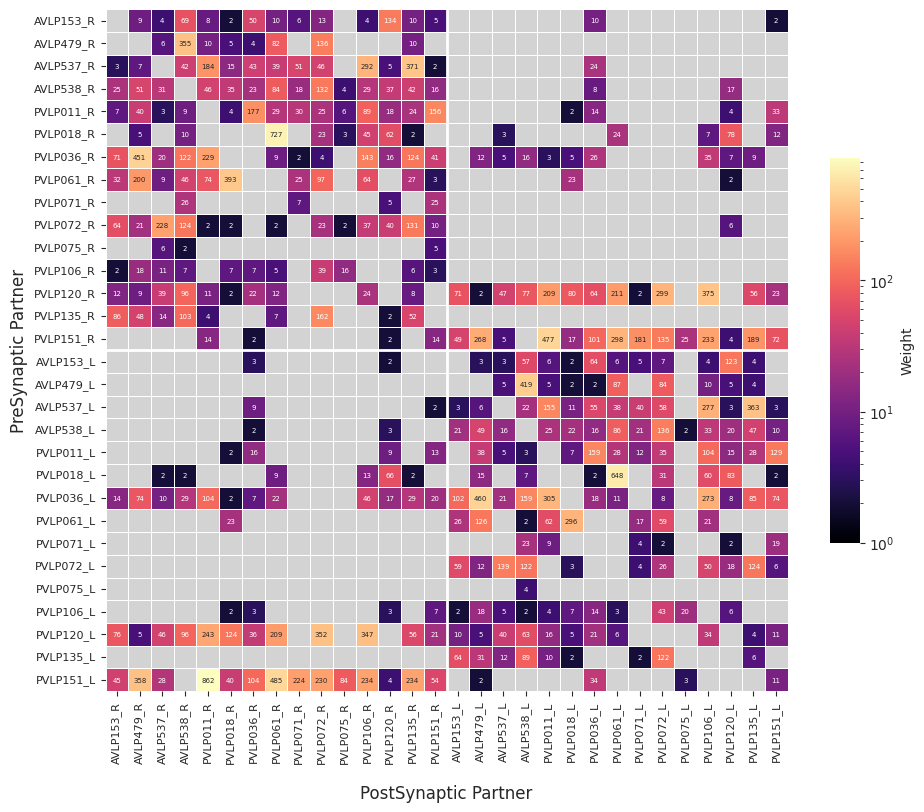

In [9]:
fig, ax = plt.subplots(figsize = (11, 10))

ax.set_facecolor("lightgrey")
# Place heatmap
sns.heatmap(partner_matrix,
            norm   = LogNorm(1, partner_matrix.values.max()),
            cmap   = "magma",
            mask   = partner_matrix == 0,
            square = True,
            linewidths = 0.5,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 0,
                         "size"     : 5},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 0.5,
                         "aspect" : 13},
            xticklabels = True,
            yticklabels = True)

# Split the hemispheres
n_right = (sources.drop_duplicates("node")["side"] == "R").sum()
ax.axhline(n_right, color = "white", linewidth = 2)
ax.axvline(n_right, color = "white", linewidth = 2)

# Labels
ax.set_ylabel("PreSynaptic Partner", fontsize = 12);
ax.set_xlabel("PostSynaptic Partner", labelpad = 15, fontsize = 12);

# Tick params
ax.tick_params(axis = "both", labelsize = 8)

# Save
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Partner-Inter-Connectivity.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Partner-Inter-Connectivity.png",
            dpi = 600,
            bbox_inches = "tight")

## Removing the LPLC1 / LPLC2 Pathways

Same as the hemibrain.

In [10]:
# Direct LC17 partners sit in the first layer
layer_zero = np.unique(sources["type"])
lplc       = ["LPLC1", "LPLC2"]

# Connections from the LC17 partners onto LPLC1 / LPLC2
to_lplc = network_df.loc[network_df["type_post"].isin(lplc) &
                         network_df["type_pre"].isin(layer_zero)]
to_lplc = to_lplc.groupby(["type_pre", "type_post"]).agg(weight    = ("weight", "sum"),
                                                        n_neurons = ("bodyId_post", "nunique")).reset_index()

# Pathways through LPLC1 / LPLC2, and how many of those run through PVLP011
has_lplc    = clean_paths.groupby(group_key)["type"].transform(lambda x : x.isin(lplc).any())
has_pvlp011 = clean_paths.groupby(group_key)["type"].transform(lambda x : (x == "PVLP011").any())

print(f"Pathways through LPLC1 / LPLC2 : {clean_paths[has_lplc].groupby(group_key).ngroups}")
print(f"  of which through PVLP011     : {clean_paths[has_lplc & has_pvlp011].groupby(group_key).ngroups}")

# Take a look
to_lplc.sort_values("weight", ascending = False)

Pathways through LPLC1 / LPLC2 : 2524
  of which through PVLP011     : 2251


,type_pre,type_post,weight,n_neurons
3,PVLP011,LPLC2,6223,121
2,PVLP011,LPLC1,3668,133
6,PVLP151,LPLC2,558,82
4,PVLP106,LPLC1,53,13
5,PVLP120,LPLC2,14,6
0,AVLP479,LPLC2,9,3
1,AVLP538,LPLC2,2,1


In [11]:
# Drop the pathways through LPLC1 / LPLC2
no_lplc_paths = clean_paths[~has_lplc]

# Size Difference
dropped = clean_paths.groupby(group_key).ngroups - no_lplc_paths.groupby(group_key).ngroups

# Display
print(f"Dropped Pathways : {dropped}")
print(f"Remaining Pathways : {no_lplc_paths.groupby(group_key).ngroups}")

Dropped Pathways : 2524
Remaining Pathways : 41049


## Flow to the DNs

Same flow as the hemibrain, only within the network we already have (after removing LPLC1 / LPLC2):

1) Every partner starts with its output synapses
2) Every neuron splits what it gets between its targets, based on how many synapses it makes onto each
3) Whatever lands on a DN stays there, since the connections out of the DNs were removed

Only the connections back onto the partners we start from are removed. The partners on the other side are just like any other neuron downstream - Right partners can pass through Left partners (like `PVLP120_R -> PVLP151_L`), and that flow is kept.

No ranking or picking here. Running it twice, once starting from only the Right partners and once from only the Left partners, and keeping the side of every DN.

The score is the % of that side's partner output that ends up at each DN.

A DN with a star (like `*DNp01_R`) is not in the network at all - that side only ever shows up on 3 hop pathways, and the network is built from the 1 and 2 hop ones. It is kept in the plot as an empty row so both sides of every DN type are there.

In [12]:
# The network after removing LPLC1 / LPLC2
dn_ids = np.unique(no_lplc_paths.loc[no_lplc_paths["size"] < max_hops, "bodyId"])
dn_net = network_df.loc[network_df["bodyId_pre"].isin(dn_ids) &
                        network_df["bodyId_post"].isin(dn_ids)]

# Same rules as the network diagram
# Removing self connections
dn_net = dn_net.loc[dn_net["bodyId_pre"] != dn_net["bodyId_post"]]
# Nothing comes out of the DNs
dn_net = dn_net.loc[~(dn_net["type_pre"].str.contains("DN", na = False))]
# No back hopping to the partners - done per side in the flow, only for the side we start from

# Which of these are DNs - type and side
dn_nodes = dict(zip(dn_net["bodyId_post"], dn_net["node_post"]))
dn_nodes = {k : v for k, v in dn_nodes.items() if "DN" in v}

# Display
print(f"Neurons : {len(dn_ids)} | Edges : {len(dn_net)}")

Neurons : 542 | Edges : 24165


Converting the connectivity matrix into the fraction of each neuron's output going to each target. A function, since the connections that get removed depend on which side we start from.

In [13]:
def get_flow_matrix(partner_ids):
    """
    Connectivity matrix as the fraction of each neuron's output going to each target.

    Parameters
    ----------
    partner_ids : array
        BodyIds of the partners we start from. Only the connections back onto
        these get removed.

    Returns
    -------
    flow_matrix : DataFrame
        Fraction of each neuron's output (rows) going to each target (columns).

    out_total : Series
        Total output of every neuron.

    """
    # No back hopping to the partners we start from
    side_net = dn_net.loc[~(dn_net["bodyId_post"].isin(partner_ids))]

    # Matrix
    flow_matrix = pd.crosstab(side_net.bodyId_pre, side_net.bodyId_post,
                              values = side_net.weight,
                              aggfunc = "sum").fillna(0)

    # Get all the items
    ids = list(set(dn_net["bodyId_pre"]) | set(dn_net["bodyId_post"]))
    flow_matrix = flow_matrix.reindex(index = ids, columns = ids).fillna(0)

    # Total output of every neuron
    out_total = flow_matrix.sum(axis = 1)

    # Convert to fractions - each row adds up to 1
    # DN rows are all zero, dividing by 1 just leaves them that way
    flow_matrix = flow_matrix.div(out_total.replace(0, 1), axis = 0)

    return flow_matrix, out_total

Passing it through for 3 hops, and keeping track of what lands on the DNs at every hop. Made into a function so it can run from each side.

In [14]:
def get_flow(start_ids):
    """
    Pass the output of some partners through the network and see what lands on the DNs.

    Parameters
    ----------
    start_ids : array
        BodyIds of the partners to start from.

    Returns
    -------
    arrived : DataFrame
        Flow onto every DN at every hop, as % of what the partners started with.

    """
    # Network for these partners
    flow_matrix, out_total = get_flow_matrix(start_ids)

    # Starting point - these partners with their output synapses, zero everywhere else
    flow  = out_total.where(out_total.index.isin(start_ids), 0)
    start = flow.sum()

    arrived = []
    # Loop over each hop
    for hop in range(1, max_hops + 1):

        # Pass it on
        flow = flow.dot(flow_matrix)

        # What reached the DNs this hop
        at_dn = flow.loc[flow.index.isin(dn_nodes.keys())].reset_index()
        at_dn.columns = ["bodyId", "flow"]
        at_dn["hop"]  = hop

        # Append
        arrived.append(at_dn)

    # Convert to DataFrame
    arrived = pd.concat(arrived, ignore_index = True)
    arrived["node"] = arrived["bodyId"].map(dn_nodes)

    # As % of what the partners started with
    arrived["flow"] = arrived["flow"] / start * 100

    # Display
    print(f"Partner output : {start:.0f} synapses")
    print(f"Reached DNs : {arrived['flow'].sum():.1f}%")
    print(f"Still in interneurons after {max_hops} hops : {flow.loc[~(flow.index.isin(dn_nodes.keys()))].sum() / start * 100:.1f}%")

    return arrived

In [15]:
flows = []
# Loop over each side
for side in ["R", "L"]:
    print(f"\n{side} Partners")

    side_flow = get_flow(sources.loc[sources["side"] == side, "bodyId"])
    side_flow["partner_side"] = side

    # Append
    flows.append(side_flow)

# Convert to DataFrame
flows = pd.concat(flows, ignore_index = True)


R Partners
Partner output : 28340 synapses
Reached DNs : 33.6%
Still in interneurons after 3 hops : 66.4%

L Partners
Partner output : 26697 synapses
Reached DNs : 33.0%
Still in interneurons after 3 hops : 67.0%


In [16]:
# Per DN node, partner side and hop as columns
dn_flow = pd.crosstab(flows.node, [flows.partner_side, flows.hop],
                      values = flows.flow,
                      aggfunc = "sum").fillna(0)

# DN types where only one side made it into the network
# The other side still gets a row (all zeros), with a star in front of its name
dn_type = dn_flow.index.str.rsplit("_", n = 1).str[0]
missing = [f"*{t}_{side}" for t in np.unique(dn_type) for side in ["R", "L"]
           if f"{t}_{side}" not in dn_flow.index]
dn_flow = dn_flow.reindex(list(dn_flow.index) + missing).fillna(0)

# Display
print(f"Missing sides : {missing}")

# Score from each side
for side in ["R", "L"]:
    dn_flow[(side, "score")] = dn_flow[side].sum(axis = 1)

# Total from both sides of partners
dn_flow["total"] = dn_flow[("R", "score")] + dn_flow[("L", "score")]

# Keeping the L and R of the same DN type together
# Types sorted by their total across both DNs, Right DN first within a type
dn_type = dn_flow.index.str.lstrip("*").str.rsplit("_", n = 1).str[0]
dn_side = dn_flow.index.str.lstrip("*").str.rsplit("_", n = 1).str[1]
order   = pd.DataFrame({"type"       : dn_type,
                        "side"       : dn_side,
                        "type_total" : dn_flow["total"].groupby(dn_type).transform("sum").values},
                       index = dn_flow.index)
order   = order.sort_values(["type_total", "type", "side"], ascending = [False, True, False])
dn_flow = dn_flow.loc[order.index]

# Take a look
dn_flow.round(2)

Missing sides : ['*DNb09_L', '*DNp01_R', '*DNpe021_R']


partner_side     L                 R                       L total
hop              1     2     3     1     2     3 score score      
node                                                              
DNp103_R      0.76  0.71  1.25  0.10  2.49  2.25  4.84  2.73  7.57
DNp103_L      0.08  2.15  1.89  0.66  0.67  0.87  2.20  4.12  6.32
DNp06_R       1.15  0.50  0.97  0.11  1.97  2.03  4.10  2.62  6.72
DNp06_L       0.11  2.19  2.01  1.17  0.55  0.79  2.51  4.31  6.82
DNa01_R       0.00  0.88  0.96  0.00  0.78  0.84  1.62  1.84  3.46
DNa01_L       0.00  0.88  0.94  0.00  0.87  1.50  2.36  1.83  4.19
DNp23_R       0.00  0.31  0.45  0.26  1.03  0.68  1.97  0.76  2.74
DNp23_L       0.19  0.85  0.66  0.00  0.33  0.37  0.70  1.70  2.40
*DNp01_R      0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
DNp01_L       0.04  0.74  0.77  1.16  0.34  0.38  1.88  1.56  3.44
DNp09_R       0.01  0.15  0.25  0.01  0.57  0.49  1.07  0.42  1.48
DNp09_L       0.03  0.63  0.53  0.02  0.16  0.35  0.54  1.19  1.73
DNp04_R       0.37  0.14  0.19  0.06  0.34  0.21  0.61  0.70  1.30
DNp04_L       0.07  0.34  0.24  0.30  0.14  0.14  0.59  0.65  1.24
DNp11_R       0.04  0.12  0.22  0.04  0.36  0.33  0.73  0.39  1.12
DNp11_L       0.03  0.34  0.31  0.02  0.10  0.20  0.31  0.68  0.99
DNp05_R       0.00  0.13  0.19  0.10  0.27  0.25  0.62  0.32  0.95
DNp05_L       0.10  0.21  0.23  0.00  0.12  0.17  0.29  0.55  0.84
DNa02_R       0.00  0.10  0.25  0.00  0.24  0.32  0.56  0.35  0.91
DNa02_L       0.00  0.28  0.26  0.00  0.09  0.24  0.33  0.54  0.86
DNpe024_R     0.09  0.08  0.15  0.01  0.27  0.36  0.63  0.32  0.95
DNpe024_L     0.01  0.25  0.26  0.10  0.07  0.13  0.29  0.52  0.81
DNpe040_R     0.10  0.15  0.14  0.04  0.34  0.26  0.64  0.39  1.03
DNpe040_L     0.04  0.22  0.15  0.11  0.08  0.09  0.28  0.42  0.70
DNa04_R       0.00  0.06  0.24  0.00  0.33  0.15  0.49  0.30  0.79
DNa04_L       0.00  0.39  0.21  0.00  0.06  0.24  0.30  0.59  0.89
DNa03_R       0.00  0.20  0.32  0.00  0.09  0.22  0.31  0.51  0.82
DNa03_L       0.00  0.07  0.25  0.00  0.25  0.28  0.53  0.33  0.85
DNb01_R       0.00  0.22  0.06  0.00  0.04  0.12  0.16  0.28  0.44
DNb01_L       0.00  0.07  0.19  0.00  0.17  0.40  0.57  0.26  0.83
DNp03_R       0.01  0.06  0.10  0.01  0.16  0.11  0.28  0.16  0.44
DNp03_L       0.03  0.27  0.12  0.02  0.08  0.10  0.21  0.42  0.63
DNb09_R       0.07  0.12  0.35  0.00  0.13  0.32  0.45  0.54  0.99
*DNb09_L      0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
*DNpe021_R    0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
DNpe021_L     0.06  0.23  0.23  0.06  0.12  0.15  0.32  0.52  0.84
DNp07_R       0.00  0.02  0.04  0.00  0.07  0.05  0.12  0.06  0.17
DNp07_L       0.00  0.08  0.01  0.00  0.01  0.03  0.04  0.09  0.13
DNa10_R       0.00  0.00  0.02  0.00  0.04  0.04  0.09  0.02  0.11
DNa10_L       0.00  0.03  0.04  0.00  0.01  0.02  0.02  0.07  0.10

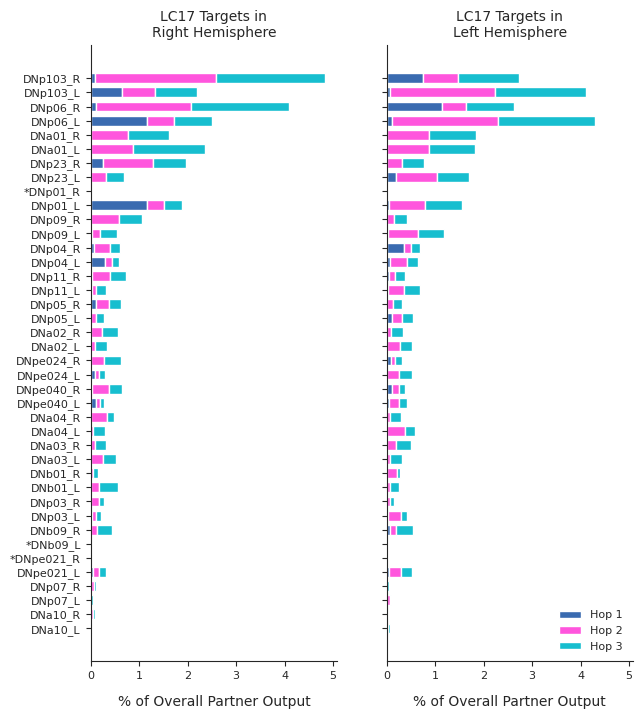

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (7, 8), sharey = True, sharex = "row")

# Colors
hop_colors = ["#3A6BB0", "#ff55dd", "#17becf"]

# One panel per partner side
for ax, side, title in zip(axes, ["R", "L"], ["LC17 Targets in\nRight Hemisphere", "LC17 Targets in\nLeft Hemisphere"]):

    # Stacking the hops
    left = np.zeros(len(dn_flow))
    for hop in range(1, max_hops + 1):
        ax.barh(range(len(dn_flow)),
                dn_flow[(side, hop)],
                left   = left,
                color  = hop_colors[hop - 1],
                height = 0.7,
                label  = f"Hop {hop}")
        left = left + dn_flow[(side, hop)]

    # Despine
    sns.despine(ax = ax)
    ax.tick_params(axis = "both", labelsize = 8)

    # Labels
    ax.set_title(title, fontsize = 10)
    ax.set_xlabel("% of Overall Partner Output", labelpad = 10)

axes[0].set_yticks(range(len(dn_flow)))
axes[0].set_yticklabels(dn_flow.index)
axes[0].invert_yaxis()
axes[1].legend(fontsize = 8, frameon = False, loc = "lower right")

# Save
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_DN-Flow.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_DN-Flow.png",
            dpi = 600,
            bbox_inches = "tight")

## Network

Same diagrams as the hemibrain, but every node is a type and side (like `PVLP061_R`), and only for the pathways starting from the Right partners. Left partners that sit along those pathways are drawn as intermediates, with the connections into them from the Right partners kept.

The neurons are organized into three categories:
1) Post-LC17
2) Intermediate
3) Descending Neurons

The Y axis follows the clustering of the connectivity, so nodes with similar partners land at the same vertical position. In the **Intermediate** layer, nodes are arranged along the X axis based on a spring-force layout.

The Left hemisphere is mirrored - every `_L` node keeps its Y but made negative, across all the layers, so the Right sits above the dotted line at zero and the Left below it.

In [18]:
# Spring layout parameters
spring_k = 1.8
spring_iterations = 400
seed = 39335

# Coordinates
x_left = 0
x_dn   = 10
x_mid_range = (1, 9)

# Colors
colors = {"left" : "#3A6BB0",
          "mid"  : "#ff55dd",
          "DN"   : "#17becf"}

# Mapping - the order matters, first match wins
categories = {
    "AVLP"      : "#ff7f0e",
    "OA | WED"  : "#808080",
    "LAL"       : "#2ca02c",
    "LT | LLPC" : "#d62728",
    "CL"        : "#bcbd22",
    "PLP"       : "#8c564b",
    "PVLP"      : "#ff55dd"}

# Edge width scale
scale = 2

Keeping only the pathways that start on one side and reach the DNs in the list.

In [19]:
def filter_paths(paths, dn_list, side):
    """
    Keep the pathways that start from the partners on one side and end on any
    of the DNs in the list.

    Parameters
    ----------
    paths : DataFrame
        Pathways, one row per node.

    dn_list : list
        DN types to keep. Empty keeps every DN.

    side : string
        Side of the partners the pathways start from, "R" or "L".

    Returns
    -------
    kept_paths : DataFrame
        The pathways from that side that reach the DNs.

    """
    # The side each pathway starts on
    start_side = paths["source"].map(sources.set_index("bodyId")["side"])
    kept_paths = paths[start_side == side]

    # The DN each pathway ends on - not any DN along the way
    if dn_list:
        end_type   = kept_paths["target"].map(targets.set_index("bodyId")["type"])
        kept_paths = kept_paths[end_type.isin(dn_list)]

    # Size Difference
    dropped = paths.groupby(group_key).ngroups - kept_paths.groupby(group_key).ngroups

    # Display
    print(f"Dropped Pathways : {dropped}")
    print(f"Remaining Pathways : {kept_paths.groupby(group_key).ngroups}")

    return kept_paths

Node level connectivity (type and side) between everything in the pathways, already in the all-to-all fetch so just subsetting it.

In [20]:
def get_node_network(paths):
    """
    Type and side level connectivity between every neuron in the pathways.

    Parameters
    ----------
    paths : DataFrame
        Pathways, one row per node.

    Returns
    -------
    node_df : DataFrame
        Edges between nodes, with the summed weight.

    """
    # Neurons to plot
    plot_ids = np.unique(paths.loc[paths["size"] < max_hops, "bodyId"])
    plot_df  = network_df.loc[network_df["bodyId_pre"].isin(plot_ids) &
                              network_df["bodyId_post"].isin(plot_ids)]

    # Group by type and side
    node_df = plot_df.groupby(["node_pre", "node_post"])["weight"].sum().reset_index()

    # Removing self connections
    node_df = node_df.loc[node_df["node_pre"] != node_df["node_post"]]
    # No back hopping to subset
    node_df = node_df.loc[~(node_df["node_post"].isin(layer_zero))]
    # We also want to remove the paths between DNs
    node_df = node_df.loc[~(node_df["node_pre"].str.contains("DN"))]
    # Removing the 5-HTP
    node_df = node_df.loc[~(node_df["node_pre"].str.contains("5-HTP")) &
                          ~(node_df["node_post"].str.contains("5-HTP"))]

    # Display
    print(f"Neurons : {len(plot_ids)} | Edges : {len(plot_df)} | Node Edges : {len(node_df)}")

    return node_df

Positions of every node. X is the layer, with the spring layout spreading out the intermediate ones, and Y is the clustering order.

In [21]:
# Direct LC17 partners sit in the first layer - only the Right ones, type and side
# The Left partners on these pathways are just intermediates here
layer_zero = np.unique(sources.loc[sources["side"] == "R", "node"])

In [22]:
def get_layout(node_df):
    """
    Graph and node positions for the network diagram.

    Parameters
    ----------
    node_df : DataFrame
        Edges between nodes, with the summed weight.

    Returns
    -------
    G_u : DiGraph
        The network.

    pos : dict
        (x, y) of every node.

    """
    # Matrix
    node_matrix = pd.crosstab(node_df.node_pre, node_df.node_post,
                              values = node_df.weight,
                              aggfunc = "sum").fillna(0).astype(int)

    # Get all the items
    neus = list(set(node_df["node_pre"]) | set(node_df["node_post"]))
    node_matrix = node_matrix.reindex(index = neus, columns = neus).fillna(0)

    # Cluster based on similarity
    cl = pd.concat((node_matrix, node_matrix.T), axis = 1)
    neu_linkage = linkage(cl, method = "ward", metric = "euclidean")
    neu_order   = leaves_list(neu_linkage)

    # Split into the three layers
    all_nodes    = set(neus)
    dn_nodes     = sorted(n for n in all_nodes if "DN" in n)
    left_nodes   = sorted(n for n in all_nodes if n in layer_zero)
    middle_nodes = sorted(n for n in all_nodes if n not in layer_zero and "DN" not in n)

    # Take a look
    print(f"Post-LC17 : {len(left_nodes)} | Intermediate : {len(middle_nodes)} | DN : {len(dn_nodes)}")

    G_u = nx.from_pandas_edgelist(node_df,
                                  "node_pre",
                                  "node_post",
                                  edge_attr = "weight",
                                  create_using = nx.DiGraph)

    rng = np.random.default_rng(seed)

    # Initial position
    init_pos = {}
    for n in left_nodes:
        init_pos[n] = np.array([x_left, rng.uniform(-3, 3)])
    for n in dn_nodes:
        init_pos[n] = np.array([x_dn, rng.uniform(-3, 3)])
    for n in middle_nodes:
        init_pos[n] = np.array([rng.uniform(-2, 2), rng.uniform(-3, 3)])

    # Fixed
    fixed = set(left_nodes) | set(dn_nodes)

    # Spring
    sp = nx.spring_layout(G_u, pos = init_pos,
                          fixed = fixed,
                          weight = "weight",
                          k = spring_k,
                          iterations = spring_iterations,
                          seed = seed)

    # Rescale the intermediate x
    mid_xs = np.array([sp[n][0] for n in middle_nodes])
    lo, hi = x_mid_range
    scaled = lo + (mid_xs - mid_xs.min()) / (np.ptp(mid_xs) + 1e-12) * (hi - lo)

    # X coordinates
    x_coord = {n : x_left for n in left_nodes}
    x_coord.update({n : x_dn for n in dn_nodes})
    x_coord.update({n : float(scaled[i]) for i, n in enumerate(middle_nodes)})

    # Y coordinates - clustering order, normalised to [0, 100]
    ordered_names = [neus[i] for i in neu_order]
    y_coord = {n : i / max(len(ordered_names) - 1, 1) * 100 for i, n in enumerate(ordered_names)}

    # Mirroring the Left hemisphere below zero, across all the layers
    y_coord = {n : -y if n.endswith("_L") else y for n, y in y_coord.items()}

    # Merging Final Positions
    pos = {n : (x_coord[n], y_coord[n]) for n in all_nodes}

    return G_u, pos

Drawing the network.

In [23]:
def get_color(node):
    """
    Color of a node, based on its layer and name.

    Parameters
    ----------
    node : string
        Neuron type and side.

    Returns
    -------
    color : string
        Hex color.

    """
    if "DN" in node:
        return colors["DN"]
    if node in layer_zero:
        return colors["left"]

    # First category whose name shows up in the node
    for names, color in categories.items():
        if any(name in node for name in names.split(" | ")):
            return color

    return colors["mid"]

#------------------------------------------------------------------------------
def plot_network(G_u, pos, filename):
    """
    Draw the network diagram and save it.

    Parameters
    ----------
    G_u : DiGraph
        The network.

    pos : dict
        (x, y) of every node.

    filename : string
        Name of the saved figure, without the extension.

    Returns
    -------
    None.

    """
    fig, ax = plt.subplots(figsize = (12, 24))
    ax.axis("off")

    # Defining edge widths
    edge_widths = np.array([w["weight"] for _, _, w in G_u.edges(data = True)])
    edge_widths = np.sqrt(edge_widths) / scale

    # Node and edge colors
    node_colors = [get_color(node) for node in G_u.nodes()]
    edge_colors = [get_color(pre) + "a1" for pre, _ in G_u.edges()]

    nx.draw_networkx(G_u,
            pos = pos,
            ax  = ax,
            node_size   = 75,
            width       = edge_widths,
            font_size   = 6,
            linewidths  = 0.25,
            edgecolors  = "black",
            with_labels = True,
            edge_color  = edge_colors,
            node_color  = node_colors)

    # Splitting the hemispheres - Right above, Left below
    ax.axhline(0, color = "grey", linestyle = ":", linewidth = 1, zorder = 0)

    # Edges
    sample = np.array([5, 25, 50, 100, 200])
    sizes  = np.sqrt(sample) / scale

    legend_elements = [
        Line2D([0], [0], color = "black", linewidth = s, label = v)
        for v, s in zip(sample, sizes)]

    # Circles
    circle_handles = [
        Line2D([0], [0], color = c,
               marker = "o",
               linestyle = "none",
               markersize = 10,
               label = k)
        for k, c in categories.items()]

    # Weight Legend
    leg1 = ax.legend(handles = legend_elements,
                     title = "Weight",
                     loc = "upper left",
                     bbox_to_anchor = (1.01, 0.9),
                     frameon = False,
                     markerscale = 0.5,
                     fontsize = 8,
                     title_fontsize = 10)
    ax.add_artist(leg1)

    # Circle Legend
    ax.legend(handles = circle_handles,
              title   = "Neuron Groups",
              loc     = "upper left",
              bbox_to_anchor = (1, 0.75),
              frameon = False,
              markerscale = 0.5,
              fontsize = 8,
              title_fontsize = 10)

    # Save it
    plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_{filename}.pdf",
                dpi = 600,
                bbox_inches = "tight")
    plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_{filename}.png",
                dpi = 600,
                bbox_inches = "tight")

### Auto Filter

Dropped Pathways : 24926
Remaining Pathways : 16123
Neurons : 294 | Edges : 11079 | Node Edges : 7120
Post-LC17 : 15 | Intermediate : 185 | DN : 25


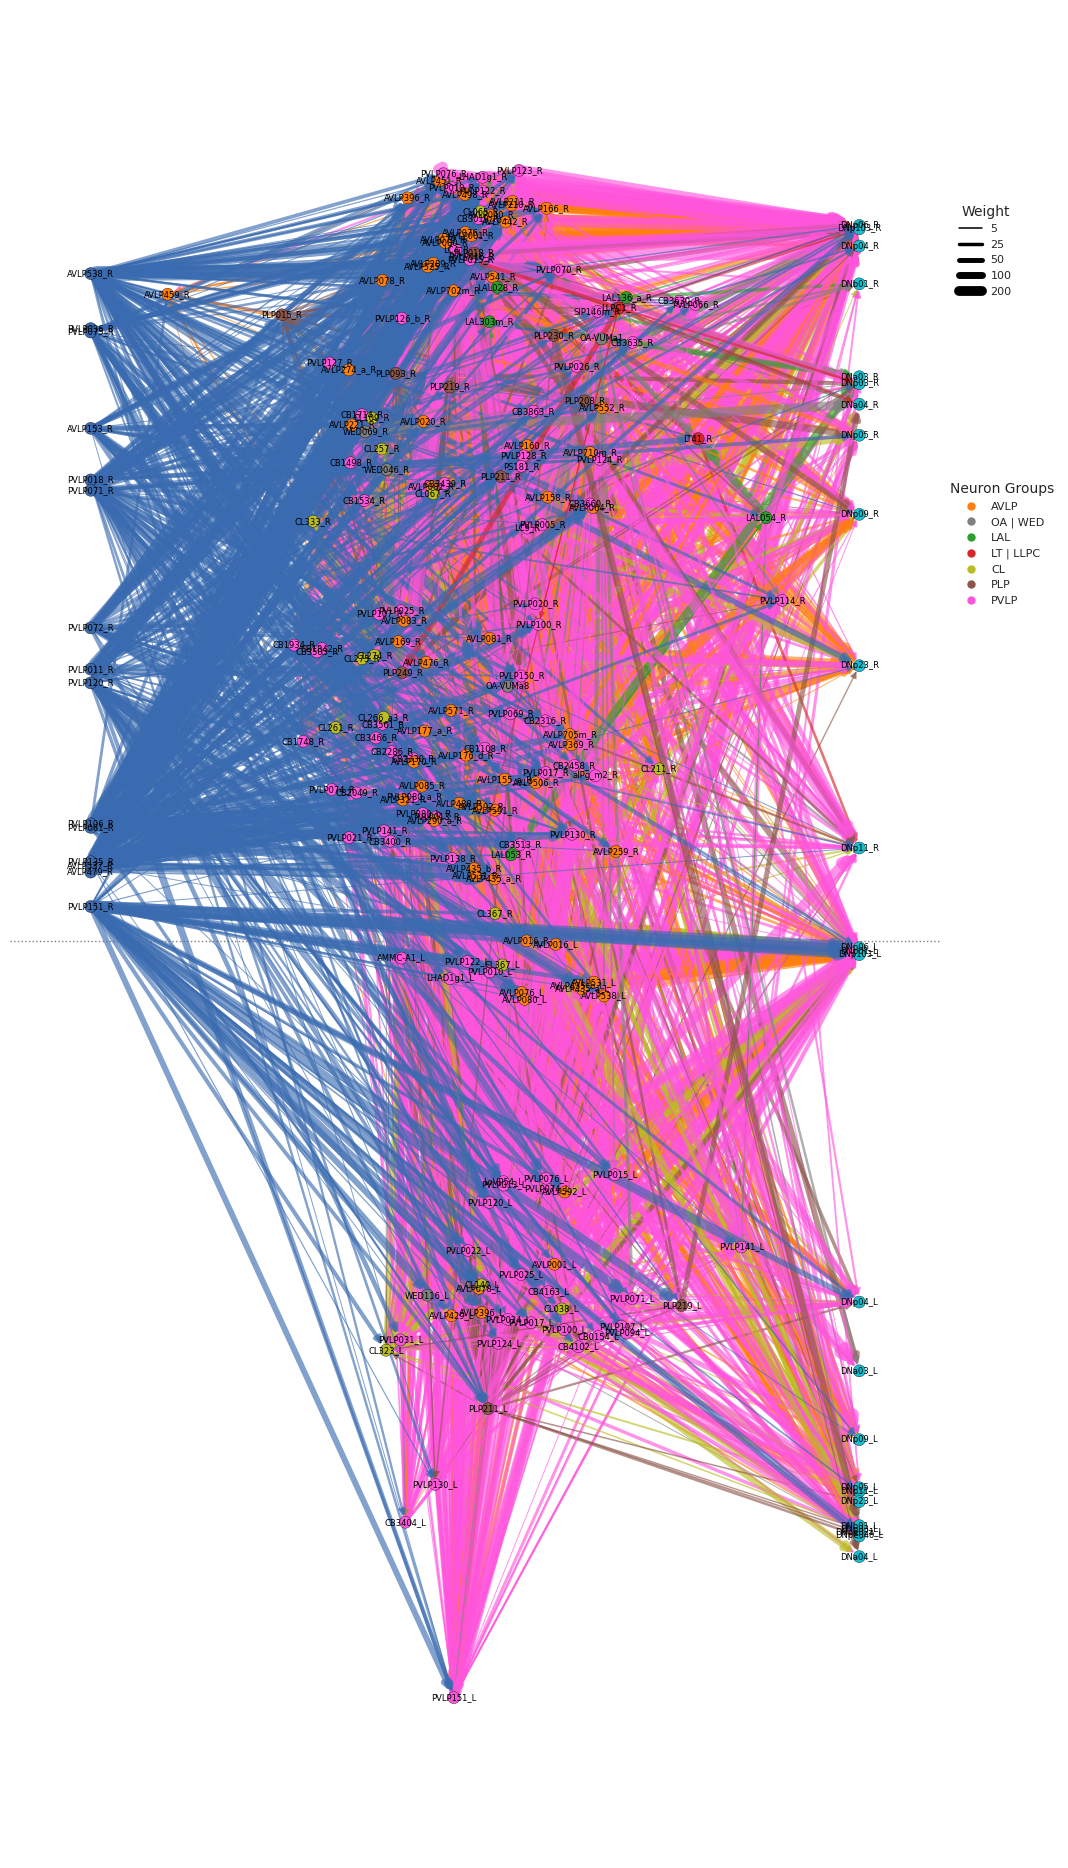

In [24]:
# Pathways from the Right partners
auto_paths = filter_paths(no_lplc_paths, auto_filter, "R")
auto_df    = get_node_network(auto_paths)

G_auto, pos_auto = get_layout(auto_df)
plot_network(G_auto, pos_auto, "Pathways-AutoFilter-R")

### Gio's Filter

Dropped Pathways : 29154
Remaining Pathways : 11895
Neurons : 145 | Edges : 2377 | Node Edges : 1567
Post-LC17 : 15 | Intermediate : 91 | DN : 17


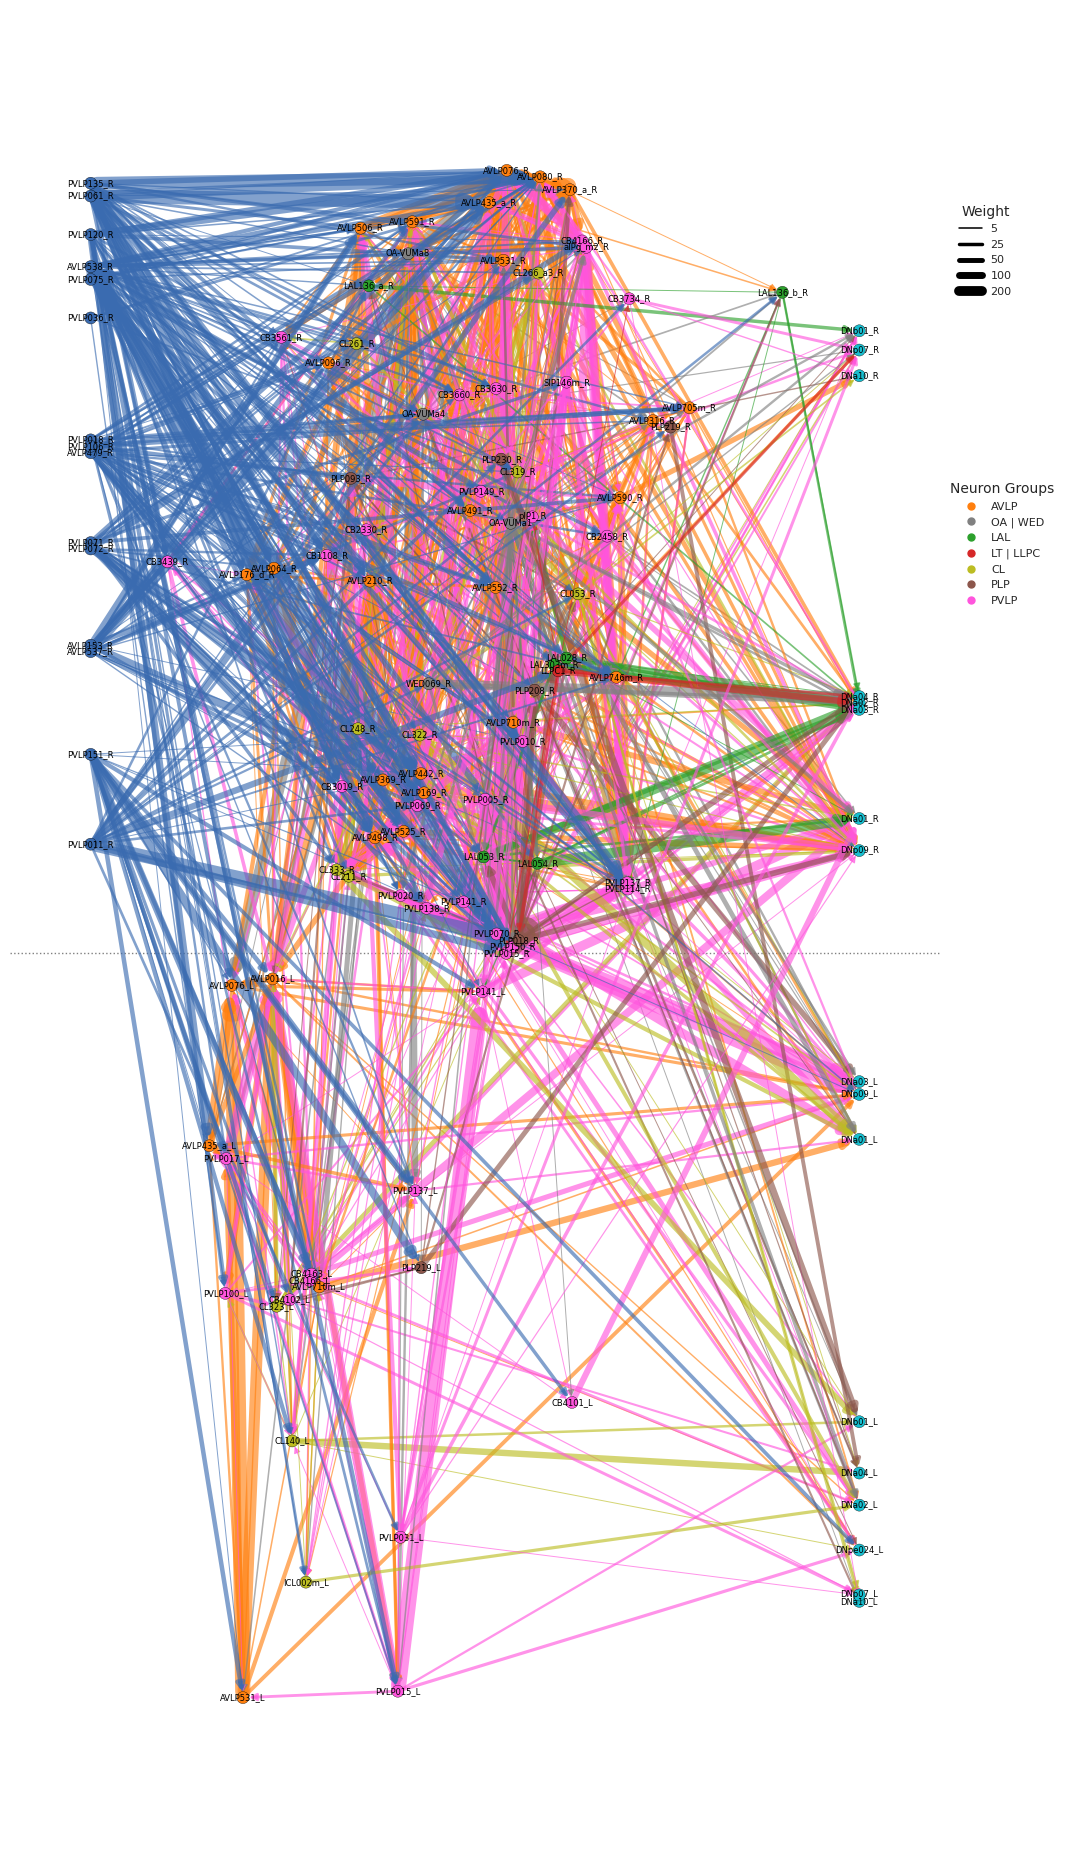

In [25]:
# Pathways from the Right partners
gio_paths = filter_paths(no_lplc_paths, gio_filter, "R")
gio_df    = get_node_network(gio_paths)

G_gio, pos_gio = get_layout(gio_df)
plot_network(G_gio, pos_gio, "Pathways-GioFilter-R")

# <center>**हो गया दोस्तों**</center>